### Parameters

In [ ]:
import sys

# Parameters
patient = globals().get("patient", None)
device = globals().get("device", None)
code_identifier = globals().get("exp_identifier", None)
exp_identifier = globals().get("exp_identifier", None)
folder_model_101 = globals().get("folder_model_101", None)
folder_model_101_s2 = globals().get("folder_model_101_s2", None)

config = globals().get("config", None)

if patient is None:
    patient = 10
if device is None:
    device = "cpu"
if exp_identifier is None:
    sys.path.insert(0, f"./../../")
    exp_identifier = '100'
if code_identifier is None:
    code_identifier = '1000'



print(f"[INFO] Training per patient: {patient}    on device: {device}   and experiment: {exp_identifier}")

[INFO] Training per patient: 10    on device: cpu   and experiment: 100


# imports

In [2]:
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pickle
import importlib
import copy
from pathlib import Path
import scipy.io as sio
import openpyxl
from pathlib import Path
import json
import os
import shutil
from pathlib import Path

from utils_SSM_100 import set_params, ensure_3d, fun_start_controller, fun_start_controller_simple, plot_glucose_insulin, modify_xlsx_row_and_column, FIT_formula, moving_average_online, LowPassFilter

# Rileva dove sei attualmente
current_dir = Path.cwd()
# Se sei dentro code/exp_X, torna alla radice
if "code" in str(current_dir):
    root = current_dir.parent.parent  # Torna a ./
else:
    root = current_dir  # Sei già alla radice
# Define simulation parameters
torch.set_default_dtype(torch.float64)

# Importa i moduli (non le funzioni da dentro)

sys.path.insert(0, f"./code/exp_{code_identifier}") 

import ParametersFunctions_SSM
import models_SSM
import SSMs
import neural_ssm
from torch.utils.data import DataLoader, random_split, Subset, SubsetRandomSampler, Dataset
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch
from dataset import LoadData, SimpleLoadData
from datetime import datetime
# Ricaricare
importlib.reload(models_SSM)
importlib.reload(SSMs)
importlib.reload(neural_ssm)
importlib.reload(ParametersFunctions_SSM)
# Adesso importa quello che ti serve
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss
from SSMs import DualSSM
from neural_ssm import DeepSSM
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch
# if not passed in papermill, set preferred values for manual use
from torch.utils.tensorboard import SummaryWriter

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


Failed to read module file 'C:\Program Files\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\env_non_lin_sys_id\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\env_non_lin_sys_id\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


# summary

In [3]:

config = config or {}

epochs_101_s1               = config.get('epochs_101_s1', 2000)
epochs_101_s2               = config.get('epochs_101_s2', 10)
epochs_s1                   = config.get('epochs_s1', 2000)
epochs_s2                   = config.get('epochs_s2', 1000)

learning_rate               = config.get('learning_rate', 1e-3)
use_monotonic_gain_loss     = config.get('use_monotonic_gain_loss', True)
loss_type_s1                = config.get('loss_type_s1', 'L1') # 'L2'
loss_type_s2                = config.get('loss_type_s2', 'L1') # 'L2'
prior_weight_s1             = config.get('prior_weight_s1', 1)
prior_weight_s2             = config.get('prior_weight_s2', 1)
use_optune                  = config.get('use_optune', True)

use_noise                   = config.get('use_noise', False)

cumulative_window           = config.get('cumulative_window', 12*2.5)
horizon                     = config.get('horizon', 12*0.5)
type_preprocess_insulin     = config.get('type_preprocess_insulin', 'sum')

use_low_pass_I              = config.get('use_low_pass_I', True)
use_low_pass_I_on_prior     = config.get('use_low_pass_I_on_prior', False)     # prior y processata dal filtro

config_optimizer_s2         = config.get('config_optimizer_s2', None)   # None se no optune


if config_optimizer_s2 is None:
    # config_optimizer_s2 = {
    # 'early_stop_epoch'          : epochs_s2,
    # 'early_stop_threshold'      : 1,
    # 'optimizers'                : ["Adam"],
    # 'lr_min_max'                : [learning_rate, learning_rate],                  
    # 'prior_weight_s2_min_max'   : [prior_weight_s2, prior_weight_s2]           
    # }
    config_optimizer_s2 = {
    'early_stop_epoch'          : 600,
    'early_stop_threshold'      : 0.01,
    'optimizers'                : ["Adam"],
    'lr_min_max'                : [1e-5, 1],                    # min e max    middle combinations included
    'prior_weight_s2_min_max'   : [1, 1000]  
    }

x0, input_dim, output_dim, dim_internal, dim_nl, y_init, IQC_type, gamma, learning_rate, epochs_s1, epochs_s2, epochs_101_s1, epochs_101_s2, data_path, model_folder, redo_save, ts, use_noise, num_days, redo_save_101_I, redo_save_101_M, exp_identifier, folder_model_101, folder_model_101_s2 = set_params(root, exp_identifier, folder_model_101, folder_model_101_s2, epochs_s1, epochs_s2, epochs_101_s1, epochs_101_s2, learning_rate, use_noise)


MODEL_PATH = Path(model_folder)
MODEL_PATH.mkdir(parents = True, exist_ok = True)

if config is not None:
    config_path = MODEL_PATH / "config.json"
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
        f.flush()  # Forza la scrittura
    print(f'config_path: {config_path}')



print(f"[INFO] Training per patient: {patient}    on device: {device}   and experiment: {exp_identifier}  with epochs_101_s1: {epochs_101_s1}, epochs_101_s2: {epochs_101_s2}, epochs_s1: {epochs_s1}, epochs_s2: {epochs_s2}")
print(f'model_folder = {model_folder}')

config_path: c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\models\SSM\exp_100_30days\config.json
[INFO] Training per patient: 10    on device: cpu   and experiment: 100  with epochs_101_s1: 2000, epochs_101_s2: 10, epochs_s1: 2000, epochs_s2: 1000
model_folder = c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients/models/SSM/exp_100_30days/


# Closed-loop data

In [4]:
#-------------------------2. Generate closed loop data---------------------------------------------


# consecutive days split
train_size = int(num_days*0.8*1440//ts)
val_size = int(num_days*0.1*1440//ts)
test_size = int(num_days*0.1*1440//ts)

start_valid = 5*12 # 5 hours of warm-up for validation and test

# it is normalized, has as method also the scaler to denormalize
dataset = LoadData(patient, data_path, use_noise, train_size+start_valid)


val_dataset   = torch.utils.data.Subset(dataset, range(train_size+start_valid, train_size+start_valid + val_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size+start_valid + val_size, train_size + val_size + test_size))

val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)



#------------------------- save scalers ---------------------------------------------------

scaler_glucose = dataset.scaler_glucose
scaler_insulin = dataset.scaler_insulin
scaler_meal    = dataset.scaler_meal


if redo_save:
    # Save the scalers
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    

    sio.savemat(MODEL_PATH / 'scalers.mat', {
    'glucose_low':  scaler_glucose.params['low'].item(),
    'glucose_high': scaler_glucose.params['high'].item(),
    'insulin_low':  scaler_insulin.params['low'].item(),
    'insulin_high': scaler_insulin.params['high'].item(),
    'meal_low':     scaler_meal.params['low'].item(),
    'meal_high':    scaler_meal.params['high'].item()
})


### Plots: I and R

c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\code\exp_1000\models_SSM.py:401: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  basal = torch.tensor(basal, dtype=torch.float32)
c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\code\exp_1000\models_SSM.py:402: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bolus = torch.tensor(bolus, dtype=torch.float32)


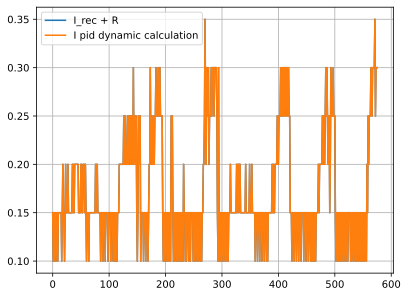

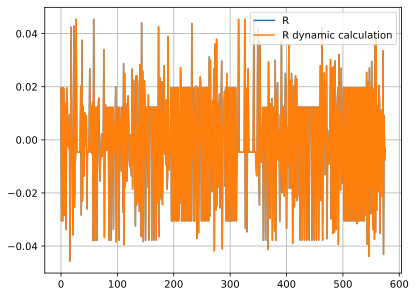

In [5]:
CGM   = (scaler_glucose.denormalize(dataset.CGM.detach())).numpy();              G     = (scaler_glucose.denormalize(dataset.G.detach())).numpy()
                                                                                                                                 
I_sat       = (scaler_insulin.denormalize(dataset.I_sat.detach())).numpy();      I_rec = (scaler_insulin.denormalize(dataset.I_rec.detach())).numpy();       
I_sat_rec   = (scaler_insulin.denormalize(dataset.I_sat_rec.detach())).numpy();  R     = (scaler_insulin.denormalize(dataset.R.detach())).numpy()

M       = (scaler_meal.denormalize(dataset.M.detach())).numpy();                 MH    = (scaler_meal.denormalize(dataset.MH.detach())).numpy();          
MH_rec  = (scaler_meal.denormalize(dataset.MH_rec.detach())).numpy()
H       = (scaler_meal.denormalize(dataset.H.detach())).numpy();                 H_rec = (scaler_meal.denormalize(dataset.H_rec.detach())).numpy();     

# R = I_sat (from .mat) - I_rec (exiting the PID and before saturation and noise)
# if  use_noise = True, R contains the noise and the saturation effect


# ------------------------- PID controller dynamic simulation ---------------------------------------------------
CGM_torch = dataset.CGM
time = dataset.time
loaded_parameters = Parameter(patient)
controller = NonLinearController(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise)
u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller(CGM_torch, time)


u_pid           = scaler_insulin.denormalize(u_pid.detach())
u_pid_rwgn      = scaler_insulin.denormalize(u_pid_rwgn.detach())
u_pid_rwgn_sat  = scaler_insulin.denormalize(u_pid_rwgn_sat.detach())
r               = scaler_insulin.denormalize(r.detach())

plt.figure()
plt.plot(I_rec[:2*1440//ts]+ R[:2*1440//ts], label= 'I_rec + R')
plt.plot(u_pid_rwgn_sat.numpy()[:2*1440//ts], label = 'I pid dynamic calculation');             plt.legend();plt.grid(True); plt.show()

plt.figure()
plt.plot(R[:2*1440//ts], label= 'R')
plt.plot(r.numpy()[:2*1440//ts], label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()


### parallelization batches

c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\code\exp_1000\models_SSM.py:618: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  basal = torch.tensor(basal, dtype=torch.float32) # MODIFICATO PER BATCH


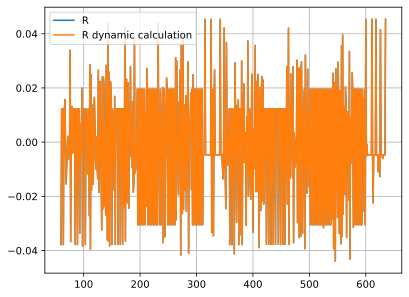

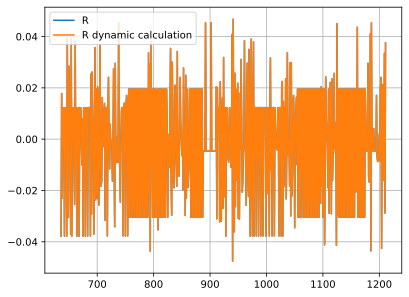

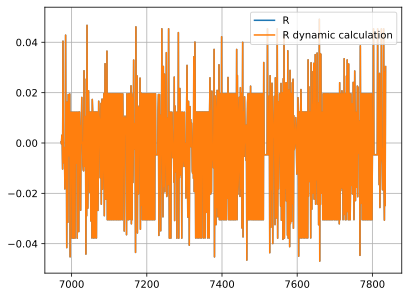

In [6]:
# train start 5 h aafter midnight, every batch 48 h long finishing at 4:55 am


# time definitions
ts_per_hour = 12           # 288 timesteps = 24h → 12 timesteps/hour (5 min each)
hours_per_batch = 48       # 2 days = 48 hours
steps_per_batch = hours_per_batch * ts_per_hour  # 48*12 = 576

start_train = start_valid        #60    [1 element every 5 minutes] I eliminate eqully the first 5 hours from training set

train_dataset = torch.utils.data.Subset(dataset, range(start_train, train_size+start_valid))



# === FUNZIONE: crea blocchi fissi ===
def create_fixed_batches(total_length, chunk_size=576, start_idx=0):
    """
    Divide il dataset in batch temporali fissi (48h).
    Ogni batch è una lista di indici consecutivi.
    L'ultimo batch viene scartato se più corto di chunk_size.
    """
    batches = []
    start = start_idx
    while start + chunk_size <= total_length:
        end = start + chunk_size
        batches.append(list(range(start, end)))
        start = end
    return batches


# === COSTRUISCI I BATCH INDICI ===
train_indices = create_fixed_batches(len(train_dataset), chunk_size=steps_per_batch)

starting_indices = [batch[0] for batch in train_indices]

batch_size=len(starting_indices)

def collate_train_indices(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset[i][0] for i in batch]) # MH # shape: (12, 576, input_dim)
    u1_batch = torch.stack([train_dataset[i][3] for i in batch]) # I_sat
    ur_batch = torch.stack([train_dataset[i][2] for i in batch]) # r
    y_batch  = torch.stack([train_dataset[i][4] for i in batch])
    time_batch = torch.stack([train_dataset[i][5] for i in batch])
    
    return u0_batch, None, ur_batch, u1_batch, y_batch, time_batch



train_loader_p = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices,
    drop_last = True  # opzionale, elimina batch incompleti
)


saturation_error_init, glucose_PID_init, y0_1 = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)

y0_0 = torch.zeros_like(y0_1) # meal ren initialized to 0

controller_p2 = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)

controller_p2.reset(saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)

# === LOOP DI TRAINING ===
for n_batch, (u0_batch, _, _, u1_batch, y_batch, time_batch) in enumerate(train_loader_p):

    u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller_p2(CGM = y_batch.squeeze(2), time = time_batch.squeeze(2))
    
r = scaler_insulin.denormalize(r.detach())
for i in range(2):
    plt.figure()
    plt.plot(time_batch[i,:].numpy(), R[time_batch[i,:].squeeze().numpy().astype(int)], label= 'R')
    plt.plot(time_batch[i,:].numpy(), r[i,:].numpy(), label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()
    
    

# === LOOP DI val ===
# !!! reset va lasciato a 0 solo se parto proprio dall'istante zero, con valid in realtà la simulazione era andata già da un po'

saturation_error_init, glucose_PID_init, y0_1 = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
controller_p2.reset(saturation_error_init=saturation_error_init, glucose_PID_init=glucose_PID_init)
for u0_batch, _, _, u1_batch, y_batch, time_batch in val_loader:
    
    u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller_p2(CGM = y_batch.squeeze(2), time = time_batch.squeeze(2))
    
r = scaler_insulin.denormalize(r.detach())

plt.figure()
plt.plot(time_batch[0,:].numpy(), R[time_batch[0,:].squeeze().numpy().astype(int)], label= 'R')
plt.plot(time_batch[0,:].numpy(), r[0,:].numpy(), label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()

### other plots

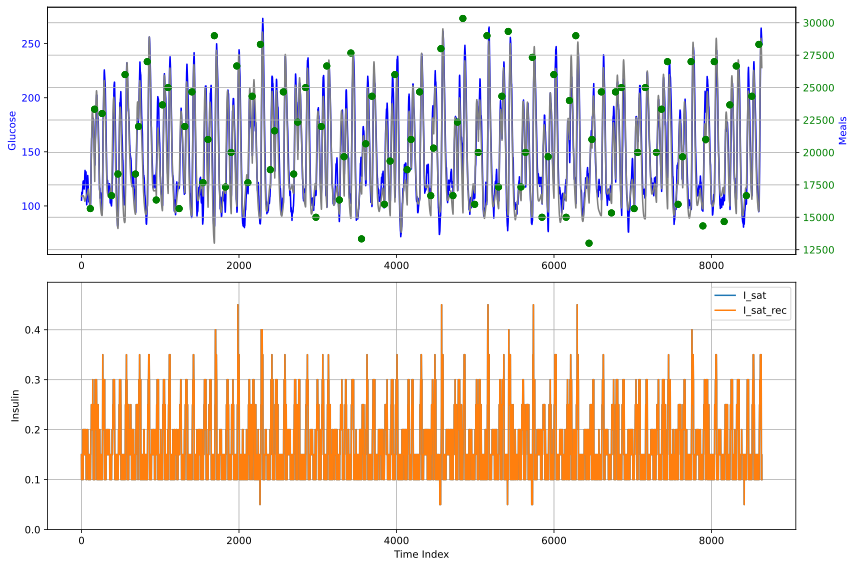

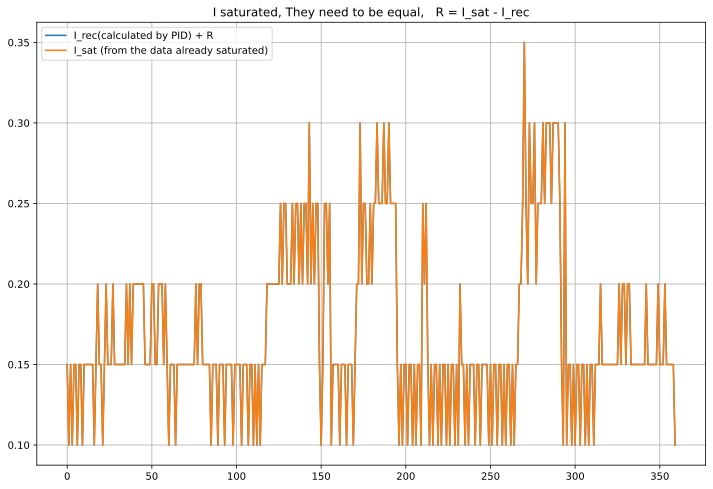

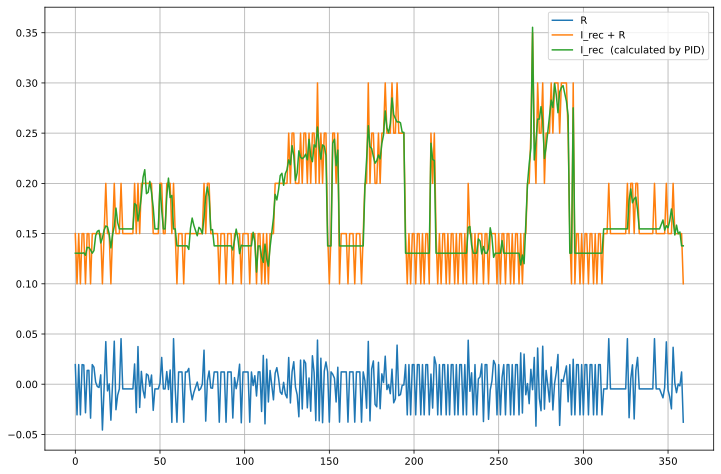

In [7]:
plt.figure(1, figsize=(12, 8))

# Subplot 1
ax1 = plt.subplot(2, 1, 1)
ax1.plot(CGM[:], 'b-', label='Glucose sensor CGM')
ax1.plot(G[:], 'gray', label='Glucose');                                                               ax1.set_ylabel('Glucose', color='b'); ax1.tick_params(axis='y', labelcolor='b'); ax1_right = ax1.twinx()
MHtemp = MH[:].copy()
ax1_right.scatter(np.arange(len(MHtemp))[MHtemp!=0], MHtemp[MHtemp!=0], color='g', label='Meals and hypo');         ax1_right.set_ylabel('Meals', color='b'); ax1_right.tick_params(axis='y', labelcolor='g'); plt.grid(True)

# Subplot 2
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(range(len(I_sat[:])), I_sat[:].flatten(), label='I_sat')
ax2.plot(range(len(I_sat_rec[:])), I_sat_rec[:], label='I_sat_rec');                                      ax2.set_ylim([0, np.max(I_sat_rec) * 1.1]); ax2.legend(); ax2.set_xlabel('Time Index'); ax2.set_ylabel('Insulin')

plt.tight_layout(); plt.grid(True); plt.show()



plt.figure(3, figsize=(12, 8))
plt.plot(I_rec[:1440//4]+ R[:1440//4], label = 'I_rec(calculated by PID) + R')
plt.plot(I_sat[:1440//4], label= 'I_sat (from the data already saturated)')
plt.title('I saturated, They need to be equal,   R = I_sat - I_rec');                   plt.legend();plt.grid(True); plt.show()

plt.figure(4, figsize=(12, 8))
plt.plot(R[:1440//4], label= 'R')
plt.plot(I_rec[:1440//4]+ R[:1440//4], label= 'I_rec + R')
plt.plot(I_rec[:1440//4], label = 'I_rec  (calculated by PID)');                             plt.legend();plt.grid(True); plt.show()


# plt.figure(5)
# plt.plot(H, label='H')
# plt.plot(H_rec-100, label='H_rec')
# plt.title('Hypoglycemia Treatments Comparison');                                                    plt.legend(); plt.show()
#
# plt.figure(6)
# plt.plot(CGM[:1440//4], 'b-', label='Glucose sensor CGM')
# plt.plot(G[:1440//4], 'gray', label='Glucose')
# plt.figure(1, figsize=(12, 8))


# Patient 101

### define dataset 101

In [8]:
dataset_101_I = SimpleLoadData(f'{root}/data/train/30days_101_I_v2/', 101,scaler_insulin, scaler_glucose, scaler_meal)
dataset_101_M = SimpleLoadData(f'{root}/data/train/30days_101_M/', 101,scaler_insulin, scaler_glucose, scaler_meal)

train_dataset_101_I = torch.utils.data.Subset(dataset_101_I, range(start_train, train_size+start_valid))
train_dataset_101_M = torch.utils.data.Subset(dataset_101_M, range(start_train, train_size+start_valid))

val_dataset_101_I   = torch.utils.data.Subset(dataset_101_I, range(train_size+start_valid, train_size+start_valid + val_size))
val_dataset_101_M   = torch.utils.data.Subset(dataset_101_M, range(train_size+start_valid, train_size+start_valid + val_size))
test_dataset_101_I  = torch.utils.data.Subset(dataset_101_I, range(train_size+start_valid + val_size, train_size + val_size + test_size))
test_dataset_101_M  = torch.utils.data.Subset(dataset_101_M, range(train_size+start_valid + val_size, train_size + val_size + test_size))

val_loader_101_I = DataLoader(val_dataset_101_I, batch_size=len(val_dataset_101_I), shuffle=False)
val_loader_101_M = DataLoader(val_dataset_101_M, batch_size=len(val_dataset_101_M), shuffle=False)
test_loader_101_I = DataLoader(test_dataset_101_I, batch_size=len(test_dataset_101_I), shuffle=False)
test_loader_101_M = DataLoader(test_dataset_101_M, batch_size=len(test_dataset_101_M), shuffle=False)


def collate_train_indices_101_I(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset_101_I[i][0] for i in batch]) # MH 
    u1_batch = torch.stack([train_dataset_101_I[i][1] for i in batch]) # I_sat   (no RWGN)
    y_batch = torch.stack([train_dataset_101_I[i][2] for i in batch]) # y
    time_batch = torch.stack([train_dataset_101_I[i][3] for i in batch])

    return u0_batch, u1_batch, y_batch, time_batch

def collate_train_indices_101_M(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset_101_M[i][0] for i in batch]) # MH 
    u1_batch = torch.stack([train_dataset_101_M[i][1] for i in batch]) # I_sat   (no RWGN)
    y_batch = torch.stack([train_dataset_101_M[i][2] for i in batch]) # y
    time_batch = torch.stack([train_dataset_101_M[i][3] for i in batch])

    return u0_batch, u1_batch, y_batch, time_batch


train_loader_p_101_I = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices_101_I,
    drop_last = True  # opzionale, elimina batch incompleti
)

train_loader_p_101_M = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices_101_M,
    drop_last = True  # opzionale, elimina batch incompleti
)



### REN model 101, loss function and optimizer parallel
as strategy 1

In [9]:
#--------------------------3. Define model for sysid---------------------------------------------


device = torch.device(device if torch.cuda.is_available() else "cpu")

y0_1 = fun_start_controller_simple(train_loader_p_101_I, dataset_101_I)
y0_0 = torch.zeros_like(y0_1) # meal ren initialized to 0


# TODO: gamma diverso per i 101

# SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 8, ff='GLU', param='l2n')  #lru   l2n gamma prescritto

SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers=7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)  


# SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU',param='l2n')

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

SSM_0_101 = SSM_0_101.to(device)
SSM_1_101 = SSM_1_101.to(device)

#create the closed loop with the identified model
# closed_loop_G = ClosedLoopSystem(REN_G, controller)

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()


### Train valid and test of 101 

#### 101 I str 1

In [ ]:

optimizer = torch.optim.Adam( list(SSM_1_101.parameters()),   lr=learning_rate)
optimizer.zero_grad()

importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

#--------------------------5. Training---------------------------------------------------------------------

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_1_101.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs_101_s1):
    # ---------------- TRAINING ---------------- #
    SSM_1_101.train()
    loss_epoch = 0.0  # Accumulate training loss
    loss_I_epoch = 0.0  # Accumulate training loss I

    for _, u1_batch, y_batch, time_batch in train_loader_p_101_I: # MH, I_rec , CGM, time        

        u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        u1_batch, y_batch, time_batch = u1_batch.to(device), y_batch.to(device), time_batch.to(device)
        
        optimizer.zero_grad()
        

        # y_init_per_batch      torch.zeros_like(y_batch[:,:1])    y_batch[:,:1]
        y1_hat_train = SSM_1_101(u1_batch) # forward
        y_hat_train = -y1_hat_train[0]
        # with monotonicity we have forced a positive response from the insulin REN (REN_1) 
        # but from real-world knowledge it is a negative relation

        loss_batch_train = MSE(y_hat_train, y_batch)
        
        loss_I_train = torch.tensor([0.0])

        total_loss_train = loss_batch_train + loss_I_train

        total_loss_train.backward()
        optimizer.step()
        loss_epoch += total_loss_train.item()
        loss_I_epoch += loss_I_train.item()
        
    loss_epoch /= len(train_loader_p)
    loss_I_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_1_101.eval()
    loss_val_epoch = 0.0
    loss_I_val_epoch = 0.0

    with torch.no_grad():
        for _, u1_batch, y_batch, time_batch in val_loader_101_I: # MH, I_rec (PID), CGM, time
            
            u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
            u1_batch, y_batch, time_batch = u1_batch.to(device), y_batch.to(device), time_batch.to(device)
            

            y1_hat_val = SSM_1_101(u1_batch)# select the correct U
            y_hat_val = -y1_hat_val[0]
            
            loss_batch_val = MSE(y_hat_val, y_batch)
            loss_I_val = torch.tensor([0.0])
        
            total_loss_val = loss_batch_val + loss_I_val
            loss_I_val_epoch += loss_I_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        
        candidate_SSM_1_101 = SSM_1_101

    loss_val_epoch /= len(val_loader)
    loss_I_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} \t||\t"
              f"Train L: {loss_epoch:.6f}   \t||\t Train L_I: {loss_I_epoch:.6f} \t||\t"
              f"Val L: {loss_val_epoch:.6f} \t||\t Val L_I: {loss_I_val_epoch:.6f}")


patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/s1/for_paz_{patient:03d}"
if redo_save_101_I:
    # model on CPU before saving
    candidate_SSM_1_101_cpu = candidate_SSM_1_101.to('cpu')

    # Save the best model
    # 1. Create models directory
    MODEL_PATH = Path(patient_model_folder_101_I)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_1_101_state_dict': candidate_SSM_1_101_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder_101_I) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

#### test 101 I str 1

In [ ]:

# --------------Plot identification results_v3_v3_v3 for G-----------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best = int(params["epoch_when_model_saved"][0].item())

print(f"epoca migliore: {epoch_best}")



# ----------------------------------

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_101_s1), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_101_s1), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 I')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n',
                    d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)


checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

#################################################################

for _, u1_batch, y_batch, time_batch in train_loader_p_101_I:

    u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    
    y1_hat = SSM_1_101(u1_batch)
    y_hat = -y1_hat[0]
    
    loss_train = MSE(y_hat, y_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    
    break # just first batch

print(f"Loss train: {loss_train}")


plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Insulin vs Time, Train')



#####################################################################################



for _, u1_batch, y_batch, time_batch in test_loader_101_I:

    u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    y1_hat = SSM_1_101(u1_batch)
    y_hat = -y1_hat[0]

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    

plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Insulin vs Time, Test')


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8, 10, 12, 14]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0_101.eval();                          SSM_1_101.eval()


    y1_hat, _ = SSM_1_101(fake_insulin)
    y_hat =  - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]

    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")


#### 101 M str 1

In [ ]:

optimizer = torch.optim.Adam( list(SSM_0_101.parameters()),   lr=learning_rate)
optimizer.zero_grad()

#--------------------------5. Training---------------------------------------------------------------------

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_0_101.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs_101_s1):
    # ---------------- TRAINING ---------------- #
    SSM_0_101.train()
    loss_epoch = 0.0  # Accumulate training loss

    
    for u0_batch, _, y_batch, time_batch in train_loader_p_101_M: # MH, I_rec (PID), CGM, time

        

        u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        u0_batch, y_batch, time_batch = u0_batch.to(device), y_batch.to(device), time_batch.to(device)
        
        optimizer.zero_grad()
        

        # y_init_per_batch      torch.zeros_like(y_batch[:,:1])    y_batch[:,:1]
        y0_hat_train = SSM_0_101(u0_batch) # forward
        y_hat_train = y0_hat_train[0]
        # with monotonicity we have forced a positive response from the insulin REN (REN_1) 
        # but from real-world knowledge it is a negative relation

        loss_batch = MSE(y_hat_train, y_batch)

        loss_batch.backward()
        optimizer.step()
        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_0_101.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for u0_batch, _, y_batch, time_batch in val_loader_101_M: # MH, I_rec (PID), CGM, time

            u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
            u0_batch, y_batch, time_batch = u0_batch.to(device), y_batch.to(device), time_batch.to(device)
            

            y0_hat_val = SSM_0_101(u0_batch)# select the correct U
            y_hat_val = y0_hat_val[0]
            
            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        
        candidate_SSM_0_101 = SSM_0_101

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")


patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/s1/for_paz_{patient:03d}"
if redo_save_101_M:
    # model on CPU before saving
    candidate_SSM_0_101_cpu = candidate_SSM_0_101.to('cpu')

    # Save the best model
    # 1. Create models directory
    MODEL_PATH = Path(patient_model_folder_101_M)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_0_101_state_dict': candidate_SSM_0_101_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder_101_M) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

#### test 101 M str 1

In [ ]:

# --------------Plot identification results for G-----------------

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]

epoch_best = int(params["epoch_when_model_saved"][0].item())
# ----------------------------------


#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_101_s1), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_101_s1), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 M')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()



SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  



checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])

#################################################################

for u0_batch, _, y_batch, time_batch in train_loader_p_101_M:

    u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    

    y0_hat = SSM_0_101(u0_batch)
    y_hat = y0_hat[0]
    
    loss_train = MSE(y_hat, y_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    u0_batch_np = scaler_meal.denormalize(u0_batch.detach().cpu()).numpy()
    
    break # just first batch

print(f"Loss train: {loss_train}")
plot_glucose_insulin(time_batch[0,:,0].numpy(), meal=u0_batch_np[0,:,0], glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Meal vs Time, Train')



#####################################################################################


for u0_batch, _, y_batch, time_batch in test_loader_101_M:

    u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    y0_hat = SSM_0_101(u0_batch)
    y_hat = y0_hat[0]

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    u0_batch_np = scaler_meal.denormalize(u0_batch.detach().cpu()).numpy()


plot_glucose_insulin(time_batch[0,:,0].numpy(), meal=u0_batch_np[0,:,0], glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Meal vs Time, Test')


# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:

    fake_meal = np.zeros(500)
    fake_meal[100] = sample 
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0_101.eval();                           SSM_1_101.eval()

    # fake_meal = scaler_glucose.normalize(fake_meal)

    y0_hat, _ = SSM_0_101(fake_meal)
    y1_hat, _ = SSM_1_101(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()


    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    # fake_meal = scaler_glucose.denormalize(fake_meal)

    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




#### 101 I str 2

In [ ]:

#-----------------------------closedloop sysid of S through RENs------------------------
#--------------------------Define model for sysid---------------------------------------------
#create the REN model for S

importlib.reload(models_SSM)
importlib.reload(SSMs)
importlib.reload(neural_ssm)
importlib.reload(ParametersFunctions_SSM)
# Adesso importa quello che ti serve
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss
from SSMs import DualSSM
from neural_ssm import DeepSSM
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101_s2}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])

SSM_1_101_s2 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

SSM_0 = copy.deepcopy(SSM_0_101.to(device))

# SSM_S = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    #  max_phase_b=0.04,  d_hidden=12, dim_amp=3)

l_filter = LowPassFilter(mode = 'real_poles')
Dual_SSM = DualSSM(SSM_0, SSM_1_101_s2, l_filter, use_low_pass_I = use_low_pass_I, device=device)

controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)
closed_loop_closed_loop_1 = ClosedLoopSystem_SSM(closed_loop_SSM, controller)


#--------------------------Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
optimizer.zero_grad()


In [ ]:
import random
import numpy as np

def set_seed(seed=42):
    """Set random seed for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[INFO] Random seed set to: {seed}")

# Set initial seed
SEED = 42 # 42
set_seed(SEED)

# ... [initialization code] ...


SSM_0, SSM_1_101_s2, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_1_101_s2.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)
train_losses = []
val_losses = []

current_seed = SEED
restart_requested = False
max_restarts = 100
restart_count = 0


if redo_save_101_I:


    while restart_count < max_restarts:
        try:
            # Ad ogni tentativo partiamo da un'epoca "logica" 0
            set_seed(current_seed)
            
            # [RE-INIZIALIZZA TUTTO QUI]
            # SSM_S, Dual_SSM, controller, closed_loop_SSM, optimizer, ecc.
            # (Sposta qui dentro la logica che avevi messo nell'if restart_requested)
            
            
            # Ricrea il modello con il nuovo seed
            SSM_1_101_s2 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                                max_phase_b=0.04,  d_hidden=12, dim_amp=3)
            l_filter = LowPassFilter(mode = 'real_poles')
            Dual_SSM = DualSSM(SSM_0, SSM_1_101_s2, l_filter, use_low_pass_I = use_low_pass_I, device=device)
            controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
            closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)
            
            SSM_0, SSM_1_101_s2, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_1_101_s2.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)
            optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
            
            train_losses = []
            val_losses = []
            epoch = 0
            min_val_loss = float('inf')
                    
                    
            for epoch in range(epochs_101_s2):


                
                # ---------------- TRAINING ---------------- #
                closed_loop_SSM.train()
                loss_epoch = 0.0

                for u0_batch, u1_batch, y_batch, time_batch in train_loader_p_101_I: # MH, I_rec , CGM, time   
                    
                    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
                    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
                    u_batch = torch.cat((u0_batch, u1_batch), dim=2)

                    optimizer.zero_grad()
                    
                    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
                    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
                    
                    if epoch < 10:
                        u_batch = u_batch[:,:250,:]
                        u1_batch = u1_batch[:,:250,:]
                        t_batch = t_batch[:,:250,:]
                        y_batch = y_batch[:,:250,:]
                        
                    
                    _, y_hat_train, y0_hat_train, y1_hat_train = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])
                    
                    if torch.isnan(y_hat_train).any() or torch.max(torch.abs(y_hat_train)) > 10000:
                        raise RuntimeError("EXPLOSION DETECTED: Values are NaN or too high")


                    loss_batch = MSE(y_hat_train, y_batch)
                    

                    if loss_type_s2 == 'L2':
                        loss_batch   **= 2
                                        
                    total_loss_batch = loss_batch 
                    
                    total_loss_batch.backward()
                    optimizer.step()
                    loss_epoch += total_loss_batch.item()
                        

                loss_epoch /= len(train_loader_p)
                train_losses.append(loss_epoch)

                # ---------------- VALIDATION ---------------- #
                Dual_SSM.eval()
                loss_val_epoch = 0.0

                with torch.no_grad():
                    for u0_batch, u1_batch, y_batch, time_batch in val_loader_101_I: # MH, I_rec (PID), CGM, time
                        
            
                        u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
                        u_batch = torch.cat((u0_batch, u1_batch), dim=2)
                        u_batch, y_batch, t_batch = u_batch.to(device), y_batch.to(device), t_batch.to(device)
                                    
                        saturation_error_init, glucose_PID_init, _ = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
                        closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
                        
                        if epoch < 10:
                            u_batch = u_batch[:,:250,:]
                            u1_batch = u1_batch[:,:250,:]
                            t_batch = t_batch[:,:250,:]
                            y_batch = y_batch[:,:250,:]
                        
                                
                        _, y_hat_val, y0_hat_val, y1_hat_val = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])
                        
                        if torch.isnan(y_hat_val).any() or torch.max(torch.abs(y_hat_val)) > 10000:
                            raise RuntimeError("EXPLOSION DETECTED: Values are NaN or too high")
                        
                        loss_batch_val = MSE(y_hat_val, y_batch)
                        
                        
                        if loss_type_s2 == 'L2':
                            loss_batch_val   **= 2
                        
                        
                        total_loss_val = loss_batch_val
                        
                        loss_val_epoch += total_loss_val.item()


                if epoch == 0 or loss_val_epoch < min_val_loss:
                    min_val_loss = loss_val_epoch
                    epoch_when_model_saved = epoch
                    candidate_Dual_SSM = Dual_SSM

                loss_val_epoch /= len(val_loader)
                val_losses.append(loss_val_epoch)

                if epoch % 1 == 0:
                    print(f"Train Loss || Epoch: {epoch} \t||\t total: {loss_epoch:.6f}  ")
                    print(f"Val   Loss || Epoch: {epoch} \t||\t total: {loss_val_epoch:.6f}  ")
                
                
            # Se arrivi alla fine delle epoche con successo:
            if epoch == epochs_101_s2 - 1:
                restart_count = max_restarts + 1 # Forza l'uscita dal while esterno
        
        except RuntimeError as e:
            if "EXPLOSION DETECTED" in str(e):
                restart_count += 1
                current_seed += 1
                print(f"\n[RESTART #{restart_count}] New seed: {current_seed}\n")
                continue # Torna all'inizio del WHILE e rifà tutto
            else:
                raise e # Se è un altro errore, ferma tutto


    # -------------------- save candidate model -----------------------
    
    candidate_Dual_SSM_cpu = candidate_Dual_SSM.to('cpu')

    patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101_s2}/s2/for_paz_{patient:03d}"

    MODEL_PATH = Path(patient_model_folder_101_I)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    torch.save({'Dual_SSM_state_dict': candidate_Dual_SSM_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')

    np_x0 = x0.detach().cpu().numpy()
    np_input_dim = np.array(input_dim)
    np_output_dim = np.array(output_dim)
    np_dim_internal = np.array(dim_internal)
    np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy()
    np_gamma = gamma.cpu().numpy()
    
    params_folder = Path(patient_model_folder_101_I) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})
    
    print(f"\n[INFO] Model saved!")
    if restart_count > 0:
        print(f"[INFO] Training completed after {restart_count} restart(s)")
        


#### test 101 I str 2

In [ ]:
# --------------Plot identification results for G-----------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101_s2}/s2/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0].item())


# ----------------------------------------------



#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_101_s2), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_101_s2), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 M')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

l_filter = LowPassFilter(mode = 'real_poles')
Dual_SSM = DualSSM(SSM_0, SSM_1, l_filter, use_low_pass_I = use_low_pass_I, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])

Dual_SSM.eval()


# --------------Plot identification results for G-----------------

tot_FIT = []
for u0_batch, u1_batch, y_batch, t_batch in train_loader_p_101_I:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p_101_I, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
    _, y_hat_train, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_train.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    for i in range(y_batch_np.shape[0]):  # itera su 12 batch
        fit_val = FIT_formula(y_true=y_batch_np[i,:,0], y_hat=y_hat_np[i,:,0])
        tot_FIT.append(fit_val)
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = False)



# ---------------------------------------------------------------


for u0_batch, u1_batch, y_batch, t_batch in test_loader_101_I:
    
    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_101_I, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat_val, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  


    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_val.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set", return_fig = False)



# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()
    
    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

plot_glucose_insulin(t_batch[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(500)
    fake_meal[100] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

plot_glucose_insulin(t_batch[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")





# Strategy 1 
System identification of G

## test 101 with data from patient i

In [ ]:

# --------------Plot identification results for G-----------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n',
                    d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)


checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

SSM_1 = copy.deepcopy(SSM_1_101.to(device))


# --------------Plot identification results for G-----------------

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)

SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])

SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_1.eval()


# -------------------------------------------------------------

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")





for u0_batch, _, _, u1_batch, y_batch, time in test_loader:   # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")



# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")


# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

    
for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")
    


## define models

In [ ]:
#--------------------------3. Define model for sysid---------------------------------------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/s1/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])


device = torch.device(device if torch.cuda.is_available() else "cpu")

l_filter = LowPassFilter(mode = 'real_poles')
SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_1 = copy.deepcopy(SSM_1_101.to(device))

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()

optimizer = torch.optim.Adam( list(SSM_0.parameters()) + list(SSM_1.parameters()),   lr=learning_rate)
optimizer.zero_grad()

# -----------

# 1. Definisci una cartella fissa per questa strategia/esperimento
# Invece di usare il timestamp nel nome, usiamo un nome fisso
log_base_dir = f"{root}/runs/exp_{exp_identifier}/training-s1/paz_{patient:03d}"
# Sottocartelle specifiche
path_loss = Path(log_base_dir) / "scalars"
path_plots = Path(log_base_dir) / "plots"

## Train

In [ ]:

#--------------------------5. Training---------------------------------------------------------------------

importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss


torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")


# 2. RIMOZIONE FISICA: Questo cancella i dati dei training precedenti
if path_loss.exists():
    shutil.rmtree(path_loss)
    print(f"[INFO] Vecchi log rimossi in: {path_loss}")

# 3. Inizializza il writer sulla cartella pulita
writer_s1_loss = SummaryWriter(log_dir=str(path_loss))
print(f"[INFO] TensorBoard pronto. Esegui: tensorboard --logdir={log_base_dir}")


SSM_0.to(device); SSM_1.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs_s1):
    # ---------------- TRAINING ---------------- #
    SSM_0.train(); SSM_1.train()
    loss_epoch, loss_epoch_I = 0.0, 0.0  # Accumulate training loss
    
    for u0_batch, _, _, u1_batch, y_batch, time_batch in train_loader_p: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time



        u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        # batch_size, time_horizon, input_dim
        u0_batch, u1_batch, y_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()

        y0_hat_train, _ = SSM_0(u0_batch) # forward
        y1_hat_train, _ = SSM_1(u1_batch) # forward
        
        if use_low_pass_I:
            y1_hat_train = l_filter(y1_hat_train) 
        
        y_hat_train = y0_hat_train - y1_hat_train 

        loss_batch = MSE(y_hat_train, y_batch)
        
        coeff_monotonic = 1 if use_monotonic_gain_loss else 0
            
        loss_batch_I = coeff_monotonic * monotonic_gain_loss(-y1_hat_train, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                        evaluate = 'insulin', 
                                                        cumulative_window = cumulative_window, 
                                                        horizon=horizon, 
                                                        aggressive_coeff=1, 
                                                        CR = loaded_parameters.Patient_par.CR,
                                                        CF = loaded_parameters.Patient_par.CF,
                                                        type_preprocess_insulin = type_preprocess_insulin, 
                                                        loaded_parameters=loaded_parameters,
                                                        use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                                        l_filter = l_filter)
        
        # y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
        # y_hat_train_np = scaler_glucose.denormalize(y_hat_train.detach().cpu()).numpy()
        # y0_hat_train_np = scaler_glucose.denormalize(y0_hat_train.detach().cpu()).numpy()
        # y1_hat_train_np = scaler_glucose.denormalize(-y1_hat_train.detach().cpu()).numpy()

        # plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), meal = u0_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_train_np[0,:,0], title='y_hat_tot')
        
        # plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), meal = u0_batch[0,:,0].numpy(), glucose=y0_hat_train_np[0,:,0], predicted_glucose=y_hat_train_np[0,:,0], title='y_hat_meal')
        
        # plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), meal = u0_batch[0,:,0].numpy(), glucose=y1_hat_train_np[0,:,0], predicted_glucose=y_hat_train_np[0,:,0], title='y_hat_insulin')

        if loss_type_s1 == 'L2':
            loss_batch   **= 2
            loss_batch_I **= 2
            
        loss_batch_I *= prior_weight_s1
            
        total_loss_batch = loss_batch + loss_batch_I


        total_loss_batch.backward()
        optimizer.step()
        loss_epoch += total_loss_batch.item()
        loss_epoch_I += loss_batch_I.item()

    loss_epoch /= len(train_loader_p)
    loss_epoch_I /= len(train_loader_p)
    
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_0.eval(); SSM_1.eval()
    loss_val_epoch, loss_val_epoch_I = 0.0, 0.0  # Accumulate training loss

    with torch.no_grad():
        for u0_batch, _, _, u1_batch, y_batch, _ in val_loader: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

            u0_batch, u1_batch, y_batch= ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch)
            u0_batch, u1_batch, y_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device)

            y0_hat_val, _ = SSM_0(u0_batch)
            y1_hat_val, _ = SSM_1(u1_batch)# select the correct U
            
            if use_low_pass_I:
                y1_hat_val = l_filter(y1_hat_val) 
            
            y_hat_val = y0_hat_val - y1_hat_val 
            
            loss_batch_val = MSE(y_hat_val, y_batch)


            coeff_monotonic = 1 if use_monotonic_gain_loss else 0

            loss_batch_I_val = coeff_monotonic *monotonic_gain_loss(-y1_hat_val, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                        evaluate = 'insulin', 
                                                        cumulative_window = cumulative_window, 
                                                        horizon=horizon, 
                                                        aggressive_coeff=1, 
                                                        CR = loaded_parameters.Patient_par.CR,
                                                        CF = loaded_parameters.Patient_par.CF,
                                                        type_preprocess_insulin = type_preprocess_insulin, 
                                                        loaded_parameters=loaded_parameters,                                                        
                                                        use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                                        l_filter = l_filter)

            if loss_type_s1 == 'L2':
                loss_batch_val   **= 2
                loss_batch_I_val **= 2
                
            loss_batch_I_val *= prior_weight_s1 
            
            total_loss_val = loss_batch_val + loss_batch_I_val
            loss_val_epoch += total_loss_val.item()
            loss_val_epoch_I += loss_batch_I_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        candidate_SSM_0 = SSM_0
        candidate_SSM_1 = SSM_1

    loss_val_epoch /= len(val_loader)
    loss_val_epoch_I /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Train Loss || Epoch: {epoch} \t||\t total: {loss_epoch:.6f} \t||\t I: {loss_epoch_I:.6f} || ")
        print(f"Val   Loss || Epoch: {epoch} \t||\t total: {loss_val_epoch:.6f} \t||\t I: {loss_val_epoch_I:.6f} || ")
    
    # GRAFICO 1: Train vs Val
    writer_s1_loss.add_scalars(f'str_1/paz_{patient:03d}/Total', {
        'train': loss_epoch,
        'val': loss_val_epoch,
    }, epoch)

    writer_s1_loss.add_scalars(f'str_1/paz_{patient:03d}/Train', {
        'total': loss_epoch,
        'MSE': loss_epoch - loss_epoch_I,
        'prior': loss_epoch_I
    }, epoch)

    writer_s1_loss.add_scalars(f'str_1/paz_{patient:03d}/Val', {
        'total': loss_val_epoch,
        'MSE': loss_val_epoch - loss_val_epoch_I,
        'prior': loss_val_epoch_I
    }, epoch)
    
    writer_s1_loss.flush()

if redo_save:
    # model on CPU before saving
    candidate_SSM_0_cpu = candidate_SSM_0.to('cpu')
    candidate_SSM_1_cpu = candidate_SSM_1.to('cpu')

    # Save the best model
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
    
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_0_state_dict': candidate_SSM_0_cpu.state_dict(),
    'SSM_1_state_dict': candidate_SSM_1_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})
    
writer_s1_loss.close()


## smal test to debug train

In [ ]:
importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 

MODEL_PATH = Path(patient_model_folder)



# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality =  monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                evaluate = 'insulin', 
                                                cumulative_window = cumulative_window, 
                                                horizon=horizon, 
                                                aggressive_coeff=1, 
                                                CR = loaded_parameters.Patient_par.CR,
                                                CF = loaded_parameters.Patient_par.CF,
                                                G_bar=torch.tensor([110]),
                                                return_debug = True,
                                                type_preprocess_insulin = type_preprocess_insulin, 
                                                loaded_parameters=loaded_parameters,                                                
                                                use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                                l_filter = l_filter)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    y0_hat_train_np = scaler_glucose.denormalize(y0_hat.detach().cpu()).numpy()
    y1_hat_train_np = scaler_glucose.denormalize(-y1_hat.detach().cpu()).numpy()
    
    time_plot = time.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y0_hat_train_np[0,:,0], title=f"y0 meal")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y1_hat_train_np[0,:,0], title=f"y1 insulin")


plt.figure(); G_bar = torch.tensor([110]);     cumulative_window = int(cumulative_window); horizon = int(horizon)
a = prior_delta_y[0,:,0].detach().cpu().numpy()
plt.plot(a, label = "prior_delta_y")
plt.plot( scaler_glucose.denormalize(y_batch[0,cumulative_window:-horizon,0]).detach().cpu().numpy() - G_bar.numpy(), label = "denorm y - G_bar")
plt.plot( delta_y_denorm[0,:,0].detach().cpu().numpy(), label = "delta_y_denorm")
plt.plot(500*torch.abs(error[0,:,0]).detach().numpy(), label = "error")
plt.plot(G_bar - scaler_glucose.denormalize(y_hat[0,:,0]).detach().cpu().numpy(), label = "G_bar - scaler_y.denormalize(y_hat)")
plt.legend()
plt.show()

In [ ]:
# patient = 10

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
MODEL_PATH = Path(patient_model_folder)

# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])
SSM_0.eval(); SSM_1.eval()
cumulative_window = int(cumulative_window); horizon = int(horizon)  

# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])
SSM_0.eval()
SSM_1.eval()

# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'
loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['G']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)

for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y1_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                            evaluate = 'insulin', 
                                            cumulative_window = cumulative_window, 
                                            horizon=horizon, 
                                            aggressive_coeff=1, 
                                            CR = loaded_parameters.Patient_par.CR,
                                            CF = loaded_parameters.Patient_par.CF,
                                            G_bar=torch.tensor([110]),
                                            return_debug = True,
                                            type_preprocess_insulin = type_preprocess_insulin, 
                                            loaded_parameters=loaded_parameters,
                                            use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                            l_filter = l_filter)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    y0_hat_np = scaler_glucose.denormalize(y0_hat.detach().cpu()).numpy()
    y1_hat_np = scaler_glucose.denormalize(-y1_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u1_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_min_value, y_min_index = torch.min(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_min_index = y_min_index.item() + u_max_index.item()
    # guarda min da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_when_u_max) - scaler_glucose.denormalize(y_min_value) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_min_index - u_max_index.item()) * 5  # in minuti
    
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")

plt.figure(figsize=(10,6))
plt.plot(time_plot[0,:,0].numpy(), y_batch_np[0,:,0], label='true y')
plt.plot(time_plot[0,:,0].numpy(), y_hat_np[0,:,0], label='predicted y')
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(), prior_delta_y[0,:,0].detach().cpu().numpy()+110, label='prior delta y')
plt.title("Test Set, insulin, prior")
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,6))
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(),scaler_glucose.denormalize(error[0,:,0]).detach().numpy(), label = "error")
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,6))
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(),prior_delta_y[0,:,0].detach().numpy(), label = "prior_delta_y")
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(),delta_y_denorm[0,:,0].detach().numpy()+75, label = "delta_y_denorm") # 
plt.legend(); plt.grid(); plt.show()

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y0_hat_np[0,:,0], title=f"Test Set, solo SSM 0")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y1_hat_np[0,:,0], title=f"Test Set, solo SSM 1")



print(f"ciao")



# -------------------------------------------------------------


## test dual SSM

In [ ]:



# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
MODEL_PATH = Path(patient_model_folder)


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

l_filter = LowPassFilter(mode = 'real_poles')
Dual_SSM = DualSSM(SSM_0, SSM_1, l_filter, use_low_pass_I = use_low_pass_I, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)



for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = False)


for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y_seq, y_SSM_0, y_SSM_1 = Dual_SSM(u0_batch, u1_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_seq.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = False)



y_seq_2 = torch.zeros_like(y_seq)
init = scaler_glucose.normalize(torch.ones_like(y_seq[:,0:1,:]) * 100)
init = -y_batch[:,0:1,:]  # meglio partire da y reale iniziale, così vediamo se SSM riesce a seguire anche con stato iniziale corretto

Dual_SSM.reset_f(init)  # reset internal states before manual forward step
for t in range(y_seq.shape[1]):
    u0_t = u0_batch[:,t:t+1,:]
    u1_t = u1_batch[:,t:t+1,:]
    y_t, _, _ = Dual_SSM.forward(u0_t, u1_t)
    y_seq_2[:,t:t+1,:] = y_t

y_hat_np = scaler_glucose.denormalize(y_seq_2.detach().cpu()).numpy()


# # ------------------------------------------


#     u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
#     saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
#     closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
#     _, y_hat_val, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = False)



## test

In [ ]:

# 2. RIMOZIONE FISICA: Questo cancella i dati dei training precedenti
if path_plots.exists():
    shutil.rmtree(path_plots)
    print(f"[INFO] Vecchi log rimossi in: {path_plots}")

# 3. Inizializza il writer sulla cartella pulita
writer_s1_plots = SummaryWriter(log_dir=str(path_plots))
print(f"[INFO] TensorBoard pronto. Esegui: tensorboard --logdir={path_plots}")




# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0].item())


# ----------------------------------

# epochs = epochs

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_s1), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_s1), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

scenarios = {'train_batch_1': 0, 'test_similar_to_train': 1, 'insulin_impulse': 2, 'meal_impulse': 3}

# --------------Plot identification results for G-----------------

tot_FIT = []

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    for i in range(y_batch_np.shape[0]):  # itera su 12 batch
        fit_val = FIT_formula(y_true=y_batch_np[i,:,0], y_hat=y_hat_np[i,:,0])
        tot_FIT.append(fit_val)
    
    # break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = False)
fig_train = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = True)
writer_s1_plots.add_figure(f'str_1/paz_{patient:03d}/Visual_Check/Train_set', fig_train); plt.show()
plt.close(fig_train) # Libera memoria

median_FIT = np.median(np.vstack(tot_FIT).flatten())

row = 1 + scenarios['train_batch_1'] * 10 + patient

modifiche = {
    f'FIT_SSM_{exp_identifier}': {
        row : median_FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# -------------------------------------------------------------


for u0_batch, _, _, u1_batch, y_batch, time in test_loader:   # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
    
    y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set", return_fig = False)
fig_test = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set", return_fig = True)
writer_s1_plots.add_figure(f'str_1/paz_{patient:03d}/Visual_Check/Test_set', fig_test); plt.show()
plt.close(fig_test) # Libera memoria


FIT = FIT_formula(y_true = y_batch_np[0,:,0], y_hat = y_hat_np[0,:,0])
row = 1 + scenarios['test_similar_to_train'] * 10 + patient

modifiche = {
    f'FIT_SSM_{exp_identifier}': {
        row : FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)

# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['G']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                            evaluate = 'insulin', 
                                            cumulative_window = cumulative_window, 
                                            horizon=horizon, 
                                            aggressive_coeff=1, 
                                            CR = loaded_parameters.Patient_par.CR,
                                            CF = loaded_parameters.Patient_par.CF,
                                            G_bar=torch.tensor([110]),
                                            return_debug = True,
                                            type_preprocess_insulin = type_preprocess_insulin, 
                                            loaded_parameters=loaded_parameters,
                                            use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                            l_filter = l_filter)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u1_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_min_value, y_min_index = torch.min(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_min_index = y_min_index.item() + u_max_index.item()
    # guarda min da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_when_u_max) - scaler_glucose.denormalize(y_min_value) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_min_index - u_max_index.item()) * 5  # in minuti
    
    small_derivative = scaler_glucose.denormalize(y_hat[:,u_max_index:u_max_index+4,:])-scaler_glucose.denormalize(y_hat[:,u_max_index-1:u_max_index+3,:])
    max_peak, max_peak_index = torch.max(torch.abs(small_derivative[0,:,0]), dim=0)
    max_peak = small_derivative[:,max_peak_index,:].item()
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin", return_fig = False)
fig_test_I = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin", return_fig = True)
writer_s1_plots.add_figure(f'str_1/paz_{patient:03d}/Visual_Check/Test_I', fig_test_I); plt.show()
plt.close(fig_test_I) # Libera memoria

plt.figure()
plt.plot(delta_y_denorm[0,:,0].detach().cpu().numpy())
plt.title("Test Set, insulin, prior")
plt.grid()
plt.show()



# scenario	patients	delta_G_empiric	 delta_G_101_linearized 	delta_G_formula 	delta_G_SSM  delta_t_max	FIT_101_linearized	FIT_SSM

row = 1 + scenarios['insulin_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


modifiche = {
    f'p_i_{exp_identifier}': {
        row : max_peak,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3_peacks.xlsx', modifiche)


# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['G']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

    
for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u0_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_max_value, y_max_index = torch.max(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_max_index = y_max_index.item() + u_max_index.item()
    # guarda max da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_max_value) - scaler_glucose.denormalize(y_when_u_max) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_max_index - u_max_index.item()) * 5  # in minuti
    
    small_derivative = scaler_glucose.denormalize(y_hat[:,u_max_index:u_max_index+4,:])-scaler_glucose.denormalize(y_hat[:,u_max_index-1:u_max_index+3,:])
    max_peak, max_peak_index = torch.max(torch.abs(small_derivative[0,:,0]), dim=0)
    max_peak = small_derivative[:,max_peak_index,:].item()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal", return_fig = False)
fig_test_M = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal", return_fig = True)
writer_s1_plots.add_figure(f'str_1/paz_{patient:03d}/Visual_Check/Test_M', fig_test_M); plt.show()
plt.close(fig_test_M) # Libera memoria
    
    
row = 1 + scenarios['meal_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


modifiche = {
    f'p_m_{exp_identifier}': {
        row : max_peak,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3_peacks.xlsx', modifiche)


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8] # vanno bene come numeri denormalizzati

for sample in  fake_insulins:

    Sim_time = 5000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[350] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    fake_meal = scaler_meal.normalize(fake_meal)
    fake_insulin = scaler_insulin.normalize(fake_insulin)

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
        
    y_hat = y0_hat - y1_hat 
        
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(1000)
    fake_meal[350] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(1000)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                           SSM_1.eval()

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    
    if use_low_pass_I:
        y1_hat = l_filter(y1_hat) 
    
    y_hat = y0_hat - y1_hat 
        
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




# Strategy 2
System identification of the negative feedback of K and S

### Closed loop model of REN in negative feedback with K, loss function and optimizer

In [ ]:

#-----------------------------closedloop sysid of S through RENs------------------------
#--------------------------Define model for sysid---------------------------------------------
#create the REN model for S

importlib.reload(models_SSM)
importlib.reload(SSMs)
importlib.reload(neural_ssm)
importlib.reload(ParametersFunctions_SSM)
# Adesso importa quello che ti serve
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss
from SSMs import DualSSM
from neural_ssm import DeepSSM
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# -------------------------------------------------------------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/s2/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)


SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_S = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

l_filter = LowPassFilter(mode = 'real_poles')
Dual_SSM = DualSSM(SSM_0, SSM_S, l_filter, use_low_pass_I = use_low_pass_I, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])




#--------------------------Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
optimizer.zero_grad()

# ---- summarywriter -------


# full_log_path

# 1. Definisci una cartella fissa per questa strategia/esperimento
# Invece di usare il timestamp nel nome, usiamo un nome fisso
log_base_dir = f"{root}/runs/exp_{exp_identifier}/training-s2/paz_{patient:03d}"
# Sottocartelle specifiche
path_loss = Path(log_base_dir) / "scalars"
path_plots = Path(log_base_dir) / "plots"

# ----- remember to cancel below !!! -------


print(f"config_optimizer_s2['evaluate_at_epoch']: {config_optimizer_s2['evaluate_at_epoch']}")
print(f"config_optimizer_s2['reduction_factor']: {config_optimizer_s2['reduction_factor']}")
print(f"config_optimizer_s2['lr_min_max']: {config_optimizer_s2['lr_min_max'][0]}, {config_optimizer_s2['lr_min_max'][1]}")

config_optimizer_s2['early_stop_epoch']: 600
config_optimizer_s2['lr_min_max']: 1e-05


### Train

In [ ]:
import random
import numpy as np
import optuna

def set_seed(seed=42):
    """Set random seed for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[INFO] Random seed set to: {seed}")

# Set initial seed
SEED = 42 # 42
set_seed(SEED)

# ... [initialization code] ...


SSM_0, SSM_S, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_S.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)
train_losses = []
val_losses = []

current_seed = SEED
restart_requested = False
max_restarts = 100
restart_count = 0



# 2. RIMOZIONE FISICA: Questo cancella i dati dei training precedenti
if path_loss.exists():
    shutil.rmtree(path_loss)
    print(f"[INFO] Vecchi log rimossi in: {path_loss}")

# 3. Inizializza il writer sulla cartella pulita
writer_s2_loss = SummaryWriter(log_dir=str(path_loss))
print(f"[INFO] TensorBoard pronto. Esegui: tensorboard --logdir={log_base_dir}")

best_global_val_loss = float('inf')
candidate_Dual_SSM = None
epoch_when_model_saved = -1
epoch = -1

while restart_count < max_restarts:
    try:

        set_seed(current_seed)
        
        
        if path_loss.exists():
            shutil.rmtree(path_loss)
            print(f"[INFO] Vecchi log rimossi in: {path_loss}")

        # 3. Inizializza il writer sulla cartella pulita
        writer_s2_loss = SummaryWriter(log_dir=str(path_loss))
        
        # Ricrea il modello con il nuovo seed

        patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/s2/for_paz_{patient:03d}"
        MODEL_PATH = Path(patient_model_folder_101_I)
        
        # candidate_Dual_SSM = None
        # epoch_when_model_saved = -1
        # epoch = -1a
        
        def objective(trial):
            
            global candidate_Dual_SSM, epoch_when_model_saved, epoch, best_global_val_loss  
            
            SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
            SSM_S = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                                max_phase_b=0.04,  d_hidden=12, dim_amp=3)
            
            
            l_filter = LowPassFilter(mode = 'real_poles')
            Dual_SSM = DualSSM(SSM_0, SSM_S, l_filter, use_low_pass_I = use_low_pass_I, device=device)
            controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
            closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

            checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
            Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])
            
            SSM_0, SSM_S, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_S.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)
            optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
        
            
            # model = define_model(trial)        # se devo cambiare modello durante l'ottimizzazione (devo cambiare dei parametri)
            
            optimizer_name      = trial.suggest_categorical("optimizer", config_optimizer_s2['optimizers'])  
            lr                  = trial.suggest_float("lr", config_optimizer_s2['lr_min_max'][0], config_optimizer_s2['lr_min_max'][1], log=True)                                    # combinazioni in mezzo
            optimizer           = getattr(torch.optim, optimizer_name)(closed_loop_SSM.parameters(), lr=lr)
            prior_weight_s2     = trial.suggest_float("prior_weight_s2", config_optimizer_s2['prior_weight_s2_min_max'][0], config_optimizer_s2['prior_weight_s2_min_max'][1], log=True)                      # combinazioni in mezzo
            
            
            # -----------------------------------------------------------------
            train_losses = []
            val_losses = []
            min_val_loss = float('inf')
            
            for epoch in range(epochs_s2):
                
                closed_loop_SSM.train()
                loss_epoch, loss_epoch_I = 0.0, 0.0

                for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:
                    
                    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch)
                    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
                    u_batch = torch.cat((u0_batch, u1_batch), dim=2)

                    optimizer.zero_grad()
                    
                    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
                    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
                    
                    if epoch < 10:
                        u_batch = u_batch[:,:250,:]
                        u1_batch = u1_batch[:,:250,:]
                        t_batch = t_batch[:,:250,:]
                        y_batch = y_batch[:,:250,:]
                        
                    
                    _, y_hat_train, y0_hat_train, y1_hat_train = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])
                    
                    if torch.isnan(y_hat_train).any() or torch.max(torch.abs(y_hat_train)) > 10000:
                        raise RuntimeError("EXPLOSION DETECTED: Values are NaN or too high")


                    loss_batch = 0 * MSE(y_hat_train, y_batch)
                    
                    loss_batch_I = monotonic_gain_loss(-y1_hat_train[:,1:,:], u1_batch[:,1:,:], scaler_glucose, scaler_insulin, y_batch[:,1:,:], 
                                                                    evaluate = 'insulin', 
                                                                    cumulative_window = cumulative_window, 
                                                                    horizon=horizon, 
                                                                    aggressive_coeff=1, 
                                                                    CR = loaded_parameters.Patient_par.CR,
                                                                    CF = loaded_parameters.Patient_par.CF,
                                                                    type_preprocess_insulin = type_preprocess_insulin, 
                                                                    loaded_parameters=loaded_parameters,
                                                                    use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                                                    l_filter = l_filter)
                    
                    if loss_type_s2 == 'L2':
                        loss_batch   **= 2
                        loss_batch_I **= 2
                    
                    loss_batch_I *= prior_weight_s2
                    
                    total_loss_batch = loss_batch + loss_batch_I
                    
                    total_loss_batch.backward()
                    optimizer.step()
                    loss_epoch += total_loss_batch.item()
                    loss_epoch_I += loss_batch_I.item()
                        

                loss_epoch /= len(train_loader_p)
                loss_epoch_I /= len(train_loader_p)
                train_losses.append(loss_epoch)

                # ---------------- VALIDATION ---------------- #
                Dual_SSM.eval()
                loss_val_epoch, loss_val_epoch_I = 0.0, 0.0

                with torch.no_grad():
                    for u0_batch, _, _, u1_batch, y_batch, t_batch in val_loader:
                        
            
                        u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch)
                        u_batch = torch.cat((u0_batch, u1_batch), dim=2)
                        u_batch, y_batch, t_batch = u_batch.to(device), y_batch.to(device), t_batch.to(device)
                                    
                        saturation_error_init, glucose_PID_init, _ = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
                        closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
                        
                        if epoch < 10:
                            u_batch = u_batch[:,:250,:]
                            u1_batch = u1_batch[:,:250,:]
                            t_batch = t_batch[:,:250,:]
                            y_batch = y_batch[:,:250,:]
                        
                                
                        _, y_hat_val, y0_hat_val, y1_hat_val = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])
                        
                        if torch.isnan(y_hat_val).any() or torch.max(torch.abs(y_hat_val)) > 10000:
                            raise RuntimeError("EXPLOSION DETECTED: Values are NaN or too high")
                        
                        loss_batch_val = 0 * MSE(y_hat_val, y_batch)
                        
                        loss_batch_I_val = 1 * monotonic_gain_loss(-y1_hat_val[:,1:,:], u1_batch[:,1:,:], scaler_glucose, scaler_insulin, y_batch[:,1:,:], 
                                                            evaluate = 'insulin', 
                                                            cumulative_window = cumulative_window, 
                                                            horizon=horizon, 
                                                            aggressive_coeff=1, 
                                                            CR = loaded_parameters.Patient_par.CR,
                                                            CF = loaded_parameters.Patient_par.CF, 
                                                            type_preprocess_insulin = type_preprocess_insulin, 
                                                            loaded_parameters=loaded_parameters,
                                                            use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                                            l_filter = l_filter)
                        
                        if loss_type_s2 == 'L2':
                            loss_batch_val   **= 2
                            loss_batch_I_val **= 2
                        
                        loss_batch_I_val *= prior_weight_s2
                        
                        total_loss_val = loss_batch_val + loss_batch_I_val
                        
                        loss_val_epoch += total_loss_val.item()
                        loss_val_epoch_I += loss_batch_I_val.item()


                if epoch == 0 or loss_val_epoch < min_val_loss:
                    min_val_loss = loss_val_epoch
                    epoch_when_model_saved = epoch
                    candidate_Dual_SSM = copy.deepcopy(Dual_SSM)
                    
                
                # Aggiorna anche il best globale tra tutti i trial/restart
                if loss_val_epoch < best_global_val_loss:
                    best_global_val_loss = loss_val_epoch
                    candidate_Dual_SSM = copy.deepcopy(Dual_SSM)
                    epoch_when_model_saved = epoch

                loss_val_epoch /= len(val_loader)
                loss_val_epoch_I /= len(val_loader)
                val_losses.append(loss_val_epoch)

                if epoch % 1 == 0:
                    print(f"Train Loss || Epoch: {epoch} \t||\t total: {loss_epoch:.6f} \t||\t I: {loss_epoch_I:.6f} || ")
                    print(f"Val   Loss || Epoch: {epoch} \t||\t total: {loss_val_epoch:.6f} \t||\t I: {loss_val_epoch_I:.6f} || ")
                
                
                # GRAFICO 1: Train vs Val
                writer_s2_loss.add_scalars(f'str_2/paz_{patient:03d}/Total', {
                    'train': loss_epoch,
                    'val': loss_val_epoch,
                }, epoch)

                writer_s2_loss.add_scalars(f'str_2/paz_{patient:03d}/Train', {
                    'total': loss_epoch,
                    'MSE': loss_epoch - loss_epoch_I,
                    'prior': loss_epoch_I
                }, epoch)

                writer_s2_loss.add_scalars(f'str_2/paz_{patient:03d}/Val', {
                    'total': loss_val_epoch,
                    'MSE': loss_val_epoch - loss_val_epoch_I,
                    'prior': loss_val_epoch_I
                }, epoch)
                
                writer_s2_loss.flush()
                
                # # === PRUNING PERSONALIZZATO ===
                # if epoch == early_stop_epoch and loss_val_epoch_I > early_stop_threshold:
                #     print(f"Pruning: loss_val_epoch_I ({loss_val_epoch_I:.6f}) > soglia ({early_stop_threshold}) all'epoca {epoch}")
                #     raise optuna.exceptions.TrialPruned()
                
                # Solo se passa il tuo test, lo segnali a Optuna
                trial.report(loss_val_epoch_I, epoch)
                
                # Pruning automatico di Optuna (soft requirement)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
                
            return loss_val_epoch_I
                    
            
                
            
            print("end epoch cycle")   
            
        # study = optuna.create_study(direction="minimize", storage = f"sqlite:///{root}/my_study.db", study_name = f"optuna_s2_paz_{patient:03d}", load_if_exists=True,     
        #                             pruner=optuna.pruners.MedianPruner(n_startup_trials=3,    # aspetta 3 trial completi prima di potare
        #                             n_warmup_steps=20,    # non pota nelle prime 100 epoche
        #                             interval_steps=10      # controlla ogni 50 epoche
        #                             ) )
        
        study = optuna.create_study(
                direction="minimize",
                storage=f"sqlite:///{root}/my_study.db",
                study_name=f"optuna_s2_paz_{patient:03d}",
                load_if_exists=True,
                pruner=optuna.pruners.HyperbandPruner(
                    min_resource=config_optimizer_s2['evaluate_at_epoch'],        # inizia a valutare dal epoch 20
                    max_resource=epochs_s2, # massimo = tutte le epoche
                    reduction_factor=config_optimizer_s2['reduction_factor']     # ad ogni round taglia 2/3 dei trial
                    )
                )
        
        study.optimize(objective, n_trials=20)
        
        pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
        completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        
        print(f"Study statistics: ")
        print("     Number of finished trials: ", len(study.trials))
        print("     Number of pruned trials: ", len(pruned_trials))
        print("     Number of complete trials: ", len(completed_trials))
        
        print("Best trial:")
        trial = study.best_trial
        
        print("     Value: ", trial.value)
        
        print(" Params: ")
        for key, value in trial.params.items():
            print(f"         {key}: {value}")
            
        
        
        
        
        # -------------------------- optuna -----------------------------------
            
        # Se arrivi alla fine delle epoche con successo:
        if epoch == epochs_s2 - 1:
            restart_count = max_restarts + 1 # Forza l'uscita dal while esterno
    
    except RuntimeError as e:
        if "EXPLOSION DETECTED" in str(e):
            restart_count += 1
            current_seed += 1
            print(f"\n[RESTART #{restart_count}] New seed: {current_seed}\n")
            continue # Torna all'inizio del WHILE e rifà tutto
        else:
            raise e # Se è un altro errore, ferma tutto

if redo_save:

    if candidate_Dual_SSM is None:
        print("[WARNING] Nessun modello candidato trovato. Recupero il best trial da Optuna...")
        # Opzione 1: esci con errore esplicito
        raise RuntimeError("candidate_Dual_SSM è None: tutti i trial sono stati pruned o sono falliti.")

    
    candidate_Dual_SSM_cpu = candidate_Dual_SSM.to('cpu')

    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_2" 
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    torch.save({'Dual_SSM_state_dict': candidate_Dual_SSM_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')

    np_x0 = x0.detach().cpu().numpy()
    np_input_dim = np.array(input_dim)
    np_output_dim = np.array(output_dim)
    np_dim_internal = np.array(dim_internal)
    np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy()
    np_gamma = gamma.cpu().numpy()
    
    params_folder = Path(patient_model_folder) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})
    
    print(f"\n[INFO] Model saved!")
    if restart_count > 0:
        print(f"[INFO] Training completed after {restart_count} restart(s)")
        
# writer_s2_loss.close()

[I 2026-02-27 15:49:04,247] Using an existing study with name 'optuna_s2_paz_010' instead of creating a new one.


[INFO] Random seed set to: 42
[INFO] TensorBoard pronto. Esegui: tensorboard --logdir=c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients/runs/exp_100/training-s2/paz_010
[INFO] Random seed set to: 42
[INFO] Vecchi log rimossi in: c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\runs\exp_100\training-s2\paz_010\scalars


[W 2026-02-27 15:49:13,062] Trial 4 failed with parameters: {'optimizer': 'Adam', 'lr': 0.22644500791465025, 'prior_weight_s2': 18.88098760782969} because of the following error: RuntimeError('EXPLOSION DETECTED: Values are NaN or too high').
Traceback (most recent call last):
  File "c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\env_non_lin_sys_id\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\pogotar\AppData\Local\Temp\2\ipykernel_35448\865170267.py", line 193, in objective
    raise RuntimeError("EXPLOSION DETECTED: Values are NaN or too high")
RuntimeError: EXPLOSION DETECTED: Values are NaN or too high
[W 2026-02-27 15:49:13,063] Trial 4 failed with value None.
[I 2026-02-27 15:49:13,239] Using an existing study with name 'optuna_s2_paz_010' instead of creating a new one.



[RESTART #1] New seed: 43

[INFO] Random seed set to: 43
[INFO] Vecchi log rimossi in: c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\runs\exp_100\training-s2\paz_010\scalars
Train Loss || Epoch: 0 	||	 total: 0.046993 	||	 I: 0.046993 || 
Val   Loss || Epoch: 0 	||	 total: 0.037718 	||	 I: 0.037718 || 
Train Loss || Epoch: 1 	||	 total: 0.045306 	||	 I: 0.045306 || 
Val   Loss || Epoch: 1 	||	 total: 0.036205 	||	 I: 0.036205 || 
Train Loss || Epoch: 2 	||	 total: 0.043967 	||	 I: 0.043967 || 
Val   Loss || Epoch: 2 	||	 total: 0.034585 	||	 I: 0.034585 || 
Train Loss || Epoch: 3 	||	 total: 0.042254 	||	 I: 0.042254 || 
Val   Loss || Epoch: 3 	||	 total: 0.032716 	||	 I: 0.032716 || 
Train Loss || Epoch: 4 	||	 total: 0.040901 	||	 I: 0.040901 || 
Val   Loss || Epoch: 4 	||	 total: 0.030822 	||	 I: 0.030822 || 
Train Loss || Epoch: 5 	||	 total: 0.039565 	||	 I: 0.039565 || 
Val   Loss || Epoch: 5 	||	 to

### small test to debug train

In [ ]:
importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_2" 

MODEL_PATH = Path(patient_model_folder)



# ----------------------------------


SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

l_filter = LowPassFilter(mode = 'real_poles')
Dual_SSM = DualSSM(SSM_0, SSM_1, l_filter, use_low_pass_I = use_low_pass_I, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])

Dual_SSM.eval()

for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
    _, y_hat, y0_hat, y1_hat  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                evaluate = 'insulin', 
                                                cumulative_window = cumulative_window, 
                                                horizon=horizon, 
                                                aggressive_coeff=1, 
                                                CR = loaded_parameters.Patient_par.CR,
                                                CF = loaded_parameters.Patient_par.CF,
                                                G_bar=torch.tensor([110]),
                                                return_debug = True,
                                                type_preprocess_insulin = type_preprocess_insulin, 
                                                loaded_parameters=loaded_parameters,
                                                use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                                l_filter = l_filter)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    y0_hat_train_np = scaler_glucose.denormalize(y0_hat.detach().cpu()).numpy()
    y1_hat_train_np = scaler_glucose.denormalize(-y1_hat.detach().cpu()).numpy()
    
    time_plot = t_batch.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),  glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),                                   glucose =y_batch_np[0,:,0],  predicted_glucose=y0_hat_train_np[0,:,0], title=f"y0 meal")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),                                   glucose =y_batch_np[0,:,0],  predicted_glucose=y1_hat_train_np[0,:,0], title=f"y1 insulin")


plt.figure(); G_bar = torch.tensor([110]);     cumulative_window = int(cumulative_window); horizon = int(horizon)
a = prior_delta_y[0,:,0].detach().cpu().numpy()
plt.plot(a, label = "prior_delta_y")
plt.plot( scaler_glucose.denormalize(y_batch[0,cumulative_window:-horizon,0]).detach().cpu().numpy() - G_bar.numpy(), label = "denorm y - G_bar")
plt.plot( delta_y_denorm[0,:,0].detach().cpu().numpy(), label = "delta_y_denorm")
plt.plot(500*torch.abs(error[0,:,0]).detach().numpy(), label = "error")
plt.plot(G_bar - scaler_glucose.denormalize(y_hat[0,cumulative_window:-horizon,0]).detach().cpu().numpy(), label = "G_bar - scaler_y.denormalize(y_hat)")
plt.legend()
plt.show()

plt.figure()
plt.plot(y_hat_np[0,:,0])
plt.plot(scaler_glucose.denormalize((y0_hat.detach().cpu()-y1_hat.detach().cpu()))[0,:,0].numpy()+1)
plt.legend()
plt.show()

### test
Plots: identification results for the negative feedback of S and K

In [ ]:
# --------------Plot identification results for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_2"
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0].item())

# epochs = 200

# ----------------------------------------------


# 2. RIMOZIONE FISICA: Questo cancella i dati dei training precedenti
if path_plots.exists():
    shutil.rmtree(path_plots)
    print(f"[INFO] Vecchi log rimossi in: {path_plots}")

# 3. Inizializza il writer sulla cartella pulita
writer_s2_plots = SummaryWriter(log_dir=str(path_plots))
print(f"[INFO] TensorBoard pronto. Esegui: tensorboard --logdir={path_plots}")



# -----------------------------------------------------

#Training and Validation Loss Across Epochs
# plt.figure(figsize=(10, 6))
# plt.plot(range(epochs_s2), train_losses, label='Training Loss', color='blue')
# plt.plot(range(epochs_s2), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
# plt.xlabel('Epochs'); plt.ylabel('Loss')
# plt.title('Training and Validation Loss Across Epochs')
# plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

l_filter = LowPassFilter(mode = 'real_poles')
Dual_SSM = DualSSM(SSM_0, SSM_1, l_filter, use_low_pass_I = use_low_pass_I, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])

Dual_SSM.eval()

scenarios = {'train_batch_1': 0, 'test_similar_to_train': 1, 'insulin_impulse': 2, 'meal_impulse': 3}

# --------------Plot identification results for G-----------------

tot_FIT = []
for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
    _, y_hat_train, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_train.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    for i in range(y_batch_np.shape[0]):  # itera su 12 batch
        fit_val = FIT_formula(y_true=y_batch_np[i,:,0], y_hat=y_hat_np[i,:,0])
        tot_FIT.append(fit_val)
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = False)
fig_train = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch", return_fig = True)
writer_s2_plots.add_figure(f'str_2/paz_{patient:03d}/Visual_Check/Train_set', fig_train); plt.show()
plt.close(fig_train) # Libera memoria

median_FIT = np.median(np.vstack(tot_FIT).flatten())

row = 1 + scenarios['train_batch_1'] * 10 + patient

modifiche = {
    f'FIT_SSM_s2_{exp_identifier}_s2': {
        row : median_FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# ---------------------------------------------------------------


for u0_batch, _, _, u1_batch, y_batch, t_batch in test_loader:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat_val, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  


    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_val.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set", return_fig = False)
fig_test = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set", return_fig = True)
writer_s2_plots.add_figure(f'str_2/paz_{patient:03d}/Visual_Check/Test_set', fig_test); plt.show()
plt.close(fig_test) # Libera memoria


FIT = FIT_formula(y_true = y_batch_np[0,:,0], y_hat = y_hat_np[0,:,0])
row = 1 + scenarios['test_similar_to_train'] * 10 + patient

modifiche = { 
    f'FIT_SSM_s2_{exp_identifier}': {
        row : FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# -------------------------------------------------------------


data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_new, loaded_parameters, scaler_glucose, scaler_insulin, dataset) #probabilmente cambiare dataset
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat, y0_hat, y1_hat = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                            evaluate = 'insulin', 
                                            cumulative_window = cumulative_window, 
                                            horizon=horizon, 
                                            aggressive_coeff=1, 
                                            CR = loaded_parameters.Patient_par.CR,
                                            CF = loaded_parameters.Patient_par.CF,
                                            G_bar=torch.tensor([110]),
                                            return_debug = True,
                                            type_preprocess_insulin = type_preprocess_insulin, 
                                            loaded_parameters=loaded_parameters,
                                            use_low_pass_I_on_prior = use_low_pass_I_on_prior,
                                            l_filter = l_filter)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u1_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_min_value, y_min_index = torch.min(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_min_index = y_min_index.item() + u_max_index.item()
    # guarda min da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_when_u_max) - scaler_glucose.denormalize(y_min_value) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_min_index - u_max_index.item()) * 5  # in minuti

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin", return_fig = False)
fig_test_I = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin", return_fig = True)
writer_s2_plots.add_figure(f'str_2/paz_{patient:03d}/Visual_Check/Test_I', fig_test_I); plt.show()
plt.close(fig_test_I) # Libera memoria

plt.figure()
plt.plot(delta_y_denorm[0,:,0].detach().cpu().numpy())
plt.title("Test Set, insulin, prior")
plt.grid(); plt.show()

# scenario	patients	delta_G_empiric	 delta_G_101_linearized 	delta_G_formula 	delta_G_SSM  delta_t_max	FIT_101_linearized	FIT_SSM

row = 1 + scenarios['insulin_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_s2_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_s2_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')



# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_new, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u0_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_max_value, y_max_index = torch.max(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_max_index = y_max_index.item() + u_max_index.item()
    # guarda max da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_max_value) - scaler_glucose.denormalize(y_when_u_max) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_max_index - u_max_index.item()) * 5  # in minuti

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal", return_fig = False)
fig_test_M = plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal", return_fig = True)
writer_s2_plots.add_figure(f'str_2/paz_{patient:03d}/Visual_Check/Test_M', fig_test_M); plt.show()
plt.close(fig_test_M) # Libera memoria

row = 1 + scenarios['meal_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_s2_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_s2_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)



# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()
    
    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    plot_glucose_insulin(t_batch[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(500)
    fake_meal[100] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    plot_glucose_insulin(t_batch[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")


writer_s2_plots.flush()
writer_s2_plots.close()

